---
## Section 0 — Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,           # regression metrics
    accuracy_score, f1_score,                # classification metrics
    confusion_matrix, classification_report
)

# Chart style 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.labelsize']  = 12

# Loading the House data csv
URL = 'https://raw.githubusercontent.com/franciscadias/data/master/kc_house_data.csv'
df  = pd.read_csv(URL)



In [2]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [3]:
df.columns.to_list()

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

### 1.1  Problem Statement

**Business question**:

 *Can KC Real Estate Firm predict the selling price of a house using its physical characteristics, location, and condition to make informed pricing decisions.*

**Target variable** :

*pricing*


**Problem type:** 

*Regression:* We are using input values to predict a continuous numerical output(pricing)

---

**Features to use** :

1. `sqft_lot` — which is the size of the whole property.
Bigger lots tend to attract a big price.
2. `view` — Rating of the quality of the property's view, typically from 0 (no view) to 4 (excellent view). Those with excellent views have a higher pricing.
3. `condition` — it ranges from 0(poor) to 5(excellent) and a higher rating equals to a higher pricing.

---

**Why this matters for KC Real Estate?** :
To evaluate which factors will contribute to maximum profit

## Section 2 — Exploratory Data Analysis

### 2.1 — Shape, Columns, and Data Types

In [4]:
print(f"Shape: {df.shape[0]:} rows x {df.shape[1]} columns")
print()
df.info()

Shape: 21613 rows x 21 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            216

### 2.2 — Missing Values

In [5]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

### 2.3 — Descriptive Statistics

In [6]:
key_cols = [
 'price',
 'sqft_lot',
 'view',
 'condition',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'floors',
 'grade',
 'sqft_above',
 'sqft_basement',
 'sqft_living15',
 'sqft_lot15'
]
df[key_cols].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.142,367127.196,75000.0,321950.00,450000.00,645000.0,7700000.0
sqft_lot,21613.0,15106.968,41420.512,520.0,5040.00,7618.00,10688.0,1651359.0
view,21613.0,0.234,0.766,0.0,0.00,0.00,0.0,4.0
condition,21613.0,3.409,0.651,1.0,3.00,3.00,4.0,5.0
bedrooms,21613.0,3.371,0.930,0.0,3.00,3.00,4.0,33.0
bathrooms,21613.0,2.115,0.770,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,2079.900,918.441,290.0,1427.00,1910.00,2550.0,13540.0
floors,21613.0,1.494,0.540,1.0,1.00,1.50,2.0,3.5
grade,21613.0,7.657,1.175,1.0,7.00,7.00,8.0,13.0
sqft_above,21613.0,1788.391,828.091,290.0,1190.00,1560.00,2210.0,9410.0


**Price and sqft_lot** both show significant right-skewness, with the mean being higher than the median, and extreme maximum values suggesting potential outliers. This indicates a few very expensive properties and properties with very large lots.

**View:**  is highly positively skewed, as at least 75% of houses have no view (median = 0), while only a small number have high view ratings (up to 4). The maximum value is part of the valid rating scale and does not indicate an outlier.

**Condition:** is approximately symmetric with most houses rated around 3. Since the values range from 1 to 5, which are all valid condition ratings, there is no evidence of outliers.

### 2.4 — EDA Charts

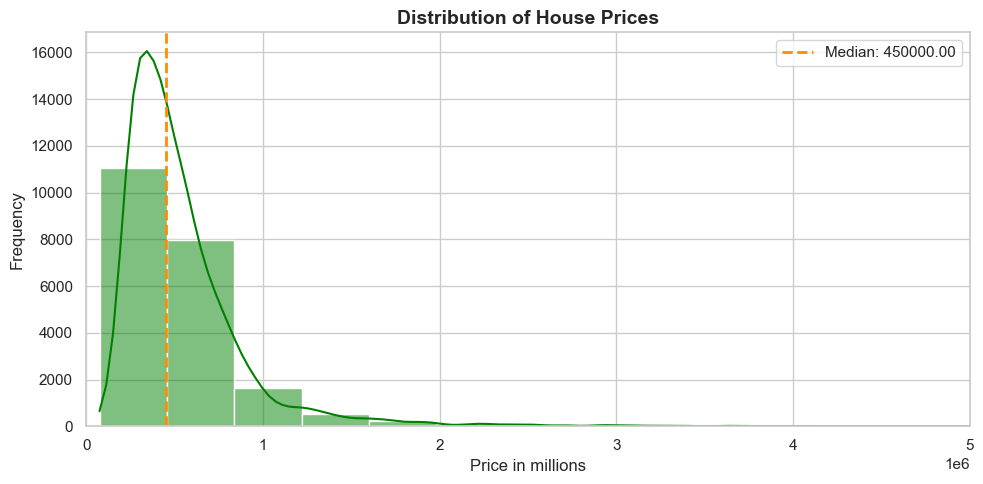

In [7]:
# Chart 1: Distribution of the target variable
# Distribution of House Prices

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='price', bins=20, kde=True, color='green')
plt.axvline(df['price'].median(), color='darkorange', linestyle='--', linewidth=2,
            label=f"Median: {df['price'].median():.2f}")
plt.legend()

plt.title('Distribution of House Prices', fontweight='bold')
plt.xlabel('Price in millions')
plt.xlim(0, 5000000)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Chart 1 interpretation**: Most houses range from approximately 200,000 to 800,000.
High-value outliers: The long right tail indicates the presence of luxury homes that are much more expensive than the majority of properties. As house prices increase, the frequency of sales decreases sharply, forming a long right tail that extends to $7.7 million.

C:\Users\lmwok\AppData\Local\Temp\ipykernel_31144\545849815.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_bucket = df.groupby('lot_bucket')['price'].mean()


<Figure size 1000x500 with 0 Axes>

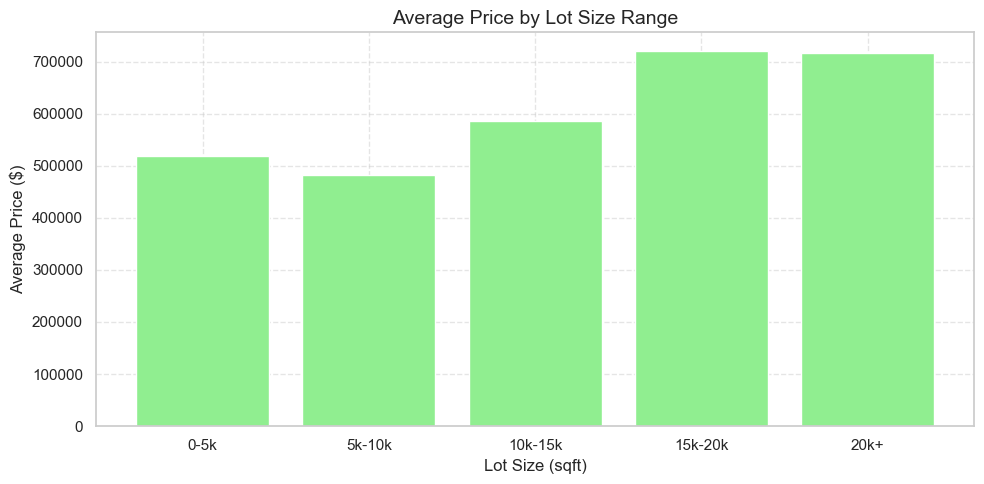

In [8]:
# ── Chart 2: Relationship between feature and target ─────────


plt.figure(figsize=(10, 5))

import pandas as pd
import matplotlib.pyplot as plt

# Creating lot size bins
df['lot_bucket'] = pd.cut(df['sqft_lot'], bins=[0, 5000, 10000, 15000, 20000, float('inf')],
                          labels=['0-5k', '5k-10k', '10k-15k', '15k-20k', '20k+'])

# Grouping by the new bins and calculate the mean price
price_by_bucket = df.groupby('lot_bucket')['price'].mean()

plt.figure(figsize=(10, 5))
plt.bar(price_by_bucket.index.astype(str),
        price_by_bucket.values,
        color='lightgreen')
plt.title("Average Price by Lot Size Range")
plt.xlabel("Lot Size (sqft)")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=0) # Keeps the labels horizontal and easy to read
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Chart 2 interpretation** :
 The chart clearly shows that the average house price generally increases with lot size indicating a positive correlation between these two variables.

In [9]:
# ── Chart 3

numeric_cols = [
  'price',
 'sqft_lot',
 'view',
 'condition',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'floors',
 'grade',
 'sqft_above',
 'sqft_basement',
 'sqft_living15',
 'sqft_lot15']

corr_matrix = df[numeric_cols].corr().round(3)

print(corr_matrix)

               price  sqft_lot   view  condition  bedrooms  bathrooms  \
price          1.000     0.090  0.397      0.036     0.308      0.525   
sqft_lot       0.090     1.000  0.075     -0.009     0.032      0.088   
view           0.397     0.075  1.000      0.046     0.080      0.188   
condition      0.036    -0.009  0.046      1.000     0.028     -0.125   
bedrooms       0.308     0.032  0.080      0.028     1.000      0.516   
bathrooms      0.525     0.088  0.188     -0.125     0.516      1.000   
sqft_living    0.702     0.173  0.285     -0.059     0.577      0.755   
floors         0.257    -0.005  0.029     -0.264     0.175      0.501   
grade          0.667     0.114  0.251     -0.145     0.357      0.665   
sqft_above     0.606     0.184  0.168     -0.158     0.478      0.685   
sqft_basement  0.324     0.015  0.277      0.174     0.303      0.284   
sqft_living15  0.585     0.145  0.280     -0.093     0.392      0.569   
sqft_lot15     0.082     0.719  0.073     -0.003   

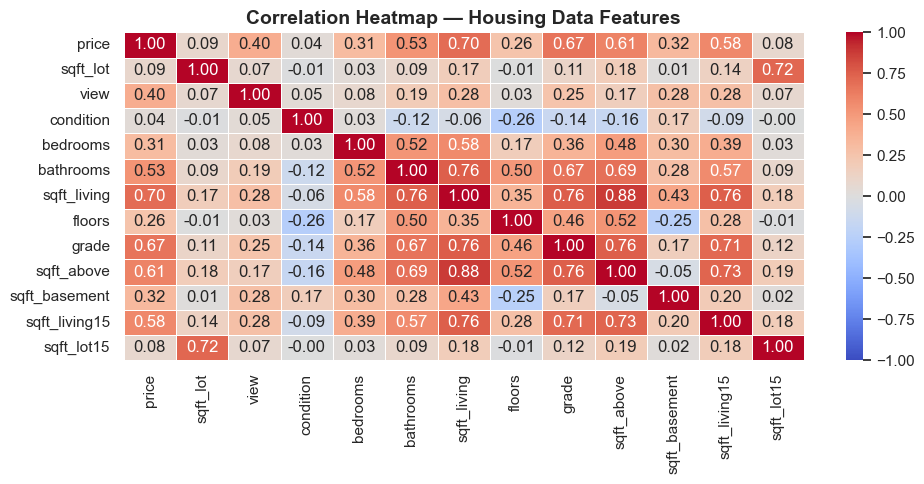

In [10]:

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_matrix,
    annot=True,        # shows the numbers inside each cell
    fmt='.2f',         # 2 decimal places
    cmap='coolwarm',   # red = positive, blue = negative
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Correlation Heatmap — Housing Data Features', fontweight='bold')
plt.tight_layout()
plt.show()

**Chart 3 interpretation** :

The correlation analysis shows that sqft_living (0.702), grade (0.667), and sqft_above (0.606) have the strongest positive linear relationships with house price. view also has a moderate positive correlation (0.397), while sqft_lot (0.090) and condition (0.036) have relatively weak linear relationships with price.

## Section 3 — Create Target Variable and Select Features

### 3.1 — Create the Target Variable

In [11]:
# CREATING TARGET COLUMN

df['Target'] = (df['price'].astype(int))
#The distribution of the target
print("Target variable distribution:")
print(df['Target'].value_counts(ascending=True))


Target variable distribution:
Target
402101       1
1151250      1
562200       1
686500       1
332900       1
          ... 
425000     150
500000     152
550000     159
450000     172
350000     172
Name: count, Length: 4028, dtype: int64



The target variable, target, represents the selling price of a house. The units are in USD and the values range from approximately 75,000  to 7,700,000. Most houses range from 350,000 to 550,000

### 3.2 — Select Features and Clean Rows

In [12]:
# ── DEFININGFEATURE COLUMNS ──────────────────────────────────────

FEATURE_COLS = ['sqft_lot', 'view', 'condition']
TARGET_COL   = 'Target'    # the column created above

df_model = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

print(f"Feature columns : {FEATURE_COLS}")
print(f"Target column   : {TARGET_COL}")
print()
print(f"Rows after filtering : {len(df_model):,}")
print(f"Rows dropped         : {len(df) - len(df_model):,}  (missing values in features or target)")
print()
print(f"X shape : {X.shape}  (rows × features)")
print(f"y shape : {y.shape}")
print()
print("First 3 rows of X:")
print(X.head(3))

Feature columns : ['sqft_lot', 'view', 'condition']
Target column   : Target

Rows after filtering : 21,613
Rows dropped         : 0  (missing values in features or target)

X shape : (21613, 3)  (rows × features)
y shape : (21613,)

First 3 rows of X:
   sqft_lot  view  condition
0      5650     0          3
1      7242     0          3
2     10000     0          3


 **Why these features?**

1. `view` — Rating of the quality of the property's view, typically from 0 (no view) to 4 (excellent view). View also has a positive correlation of 0.4, meaning those with excellent views have a higher pricing.
2. `sqft_lot` — which is the size of the whole property.
Bigger lots tend to attract a big price.
3. `condition` — it ranges from 0(poor) to 5(excellent) and a higher rating equals to a higher pricing.

## Section 4 — Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42      # same split every run
)

print(f"Training set : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set     : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.0f}%)")
print()
# Sanity check: target mean should be similar in both sets
print(f"Train target mean : {y_train.mean():.4f}")
print(f"Test  target mean : {y_test.mean():.4f}")
print()

# Calculate the 5% threshold dynamically based on the training mean
five_percent_threshold = y_train.mean() * 0.05

if abs(y_train.mean() - y_test.mean()) > five_percent_threshold:
    print("WARNING: Train and test means differ by more than 5% — check your data or try a different random_state")
else:
    print("OK: Train and test distributions are similar.")

Training set : 17,290 rows  (80%)
Test set     : 4,323 rows  (20%)

Train target mean : 537768.0479
Test  target mean : 549367.4437

OK: Train and test distributions are similar.



## Section 5 — Baseline Model



### 5.1 — Choose and Train the Baseline


LinearRegression() - This is because we are using input values to predict a continuous numerical output which is the price

In [14]:
baseline_model = LinearRegression()

# ── Train ─────────────────────────────────────────────────────────────
baseline_model.fit(X_train, y_train)

# ── Predict on test set ───────────────────────────────────────────────
y_pred_baseline = baseline_model.predict(X_test)

print(f"Baseline algorithm : {type(baseline_model).__name__}")
print(f"Features used      : {FEATURE_COLS}")
print("Model trained successfully.")

Baseline algorithm : LinearRegression
Features used      : ['sqft_lot', 'view', 'condition']
Model trained successfully.


### 5.2 — Evaluate the Baseline Model

In [15]:
# ── REGRESSION EVALUATION ─────────────────────────────────────────────
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline  = r2_score(y_test, y_pred_baseline)

# Mean-prediction baseline (always predict the training mean)
mean_pred       = [y_train.mean()] * len(y_test)
mae_mean_base   = mean_absolute_error(y_test, mean_pred)
r2_mean_base    = r2_score(y_test, mean_pred)     # always 0.0 by definition

print(f"{'Model':<35} {'MAE':>10} {'R²':>10}")
print("-" * 57)
print(f"{'Always-predict-mean (floor)':<35} {mae_mean_base:>10.4f} {r2_mean_base:>10.4f}")
print(f"{'Baseline: ' + type(baseline_model).__name__:<35} {mae_baseline:>10.4f} {r2_baseline:>10.4f}")

Model                                      MAE         R²
---------------------------------------------------------
Always-predict-mean (floor)         239998.8351    -0.0009
Baseline: LinearRegression          222618.1459     0.1716


1. The Mean Absolute Error (MAE) of 222,618.15 means, on average, the model's predictions are off by approximately $222,618 from the actual house prices. The R² score of 0.1716 indicates that about 17.16% of the variance in house prices can be explained by the features used in this model.

2. The model beats the naive baseline: its MAE is 17,380.69 lower than the always-predict-mean floor's MAE (222,618.15 vs. 239,998.84), and it has a positive R² of 0.1716, compared to the floor's near zero R².

3. This suggests that the current features are weak predictors of price, and the model has significant room for improvement by incorporating more relevant features or exploring more complex model architectures to capture more variance.

### 5.4 — Actual vs. Predicted Chart (regression only)

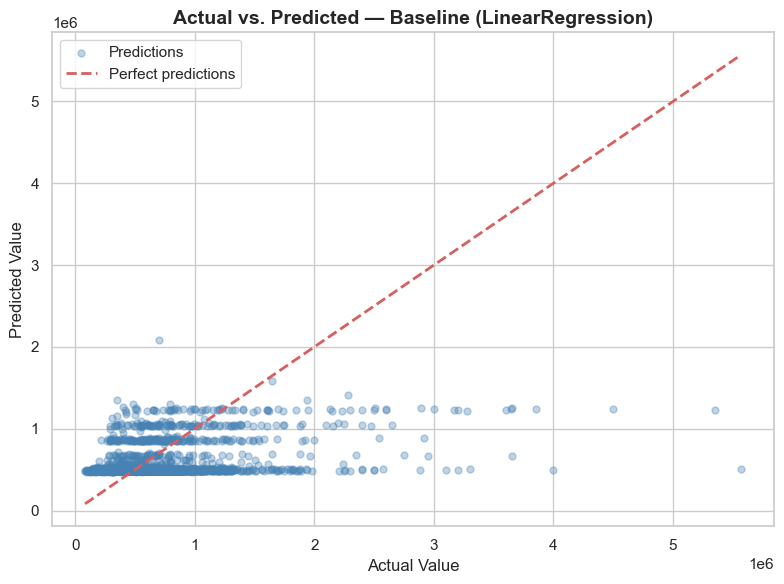

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_baseline, alpha=0.35, color='steelblue', s=25, label='Predictions')


lims = [
    min(y_test.min(), y_pred_baseline.min()),
    max(y_test.max(), y_pred_baseline.max())
]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect predictions')


plt.title(f'Actual vs. Predicted — Baseline ({type(baseline_model).__name__})', fontweight='bold')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.legend()
plt.tight_layout()
plt.show()

**Actual vs. Predicted interpretation**   
The chart shows a general trend where predicted values align with actual values, but there's a significant spread, especially for higher actual house prices. This indicates that while the model captures the overall relationship, it still has substantial error in predicting individual house prices, particularly for more expensive properties.


## Section 6 — Model Improvement


### 6.1 — Improvement Attempt 1

In [17]:
# ── IMPROVEMENT MODEL 1 ─────────────────────────────────────────────

# Update the feature list — add or change columns
FEATURE_COLS_V2 = [    'grade',
    'view',
    'sqft_living',
    'sqft_above'
]   # example: added Meta_score

# Filter rows
df_v2    = df.dropna(subset=FEATURE_COLS_V2 + [TARGET_COL]).copy()
X2       = df_v2[FEATURE_COLS_V2]
y2       = df_v2[TARGET_COL]

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# ── CLASSIFICATION — choose your improved model ───────────────────────
#improved_model = DecisionTreeClassifier(max_depth=3, random_state=42)
#improved_model = LogisticRegression(random_state=42, max_iter=1000)

# ── REGRESSION — choose your improved model ───────────────────────────
#improved_model = DecisionTreeRegressor(max_depth=4, random_state=42)
improved_model = LinearRegression()

# ── Train + predict ───────────────────────────────────────────────────
improved_model.fit(X2_train, y2_train)
y_pred_v2 = improved_model.predict(X2_test)

print(f"Improved algorithm : {type(improved_model).__name__}")
print(f"Features used      : {FEATURE_COLS_V2}")
print(f"Rows in this run   : {len(X2):,}")

Improved algorithm : LinearRegression
Features used      : ['grade', 'view', 'sqft_living', 'sqft_above']
Rows in this run   : 21,613


### 6.2 — Compare Baseline vs. Improved Model

In [18]:
# ── REGRESSION COMPARISON ─────────────────────────────────────────────

mae_v2 = mean_absolute_error(y2_test, y_pred_v2)
r2_v2  = r2_score(y2_test, y_pred_v2)

print("Model Comparison")
print("=" * 55)
print(f"{'Model':<33} {'MAE':>10} {'R²':>8}")
print("-" * 55)
print(f"{'Always-predict-mean':<33} {mae_mean_base:>10.4f} {'0.0000':>8}")
print(f"{'Baseline: ' + type(baseline_model).__name__:<33} {mae_baseline:>10.4f} {r2_baseline:>8.4f}")
print(f"{'Improved: ' + type(improved_model).__name__:<33} {mae_v2:>10.4f} {r2_v2:>8.4f}")

Model Comparison
Model                                    MAE       R²
-------------------------------------------------------
Always-predict-mean               239998.8351   0.0000
Baseline: LinearRegression        222618.1459   0.1716
Improved: LinearRegression        160877.2984   0.5764


**Did the improvement work?**
1. Yes, the improvement worked significantly. The MAE decreased by approximately $61,740.85 (from 222,618.15 to 160,877.30), and the R² score increased by approximately 0.4048 (from 0.1716 to 0.5764).

2. This substantial improvement tells us that the newly introduced features (grade, sqft_living, sqft_above) are much stronger predictors of house price than the original sqft_lot and condition features. It indicates that characteristics related to the quality and size of the living space are highly influential in determining house prices.

### 6.3 — Improvement Attempt 2 (optional — earns extra marks)

In [19]:
# ──SECOND IMPROVEMENT ATTEMPT ─────────────────────────────

FEATURE_COLS_V3 = [    'grade',
    'view',
    'sqft_living',
    'bathrooms',
    'bedrooms',
    'waterfront',
    'condition',
    'floors',
    'yr_built',
    'yr_renovated',
    'zipcode',
    'sqft_basement',
    'lat',
    'long']   

df_v3    = df.dropna(subset=FEATURE_COLS_V3 + [TARGET_COL]).copy()
X3       = df_v3[FEATURE_COLS_V3]
y3       = df_v3[TARGET_COL]

# Split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)


improved_model2 = LinearRegression()

# ── Train + predict ───────────────────────────────────────────────────
improved_model2.fit(X3_train, y3_train)
y_pred_v3 = improved_model2.predict(X3_test)

print(f"Improved algorithm : {type(improved_model2).__name__}")
print(f"Features used      : {FEATURE_COLS_V3}")
print(f"Rows in this run   : {len(X3):,}")



Improved algorithm : LinearRegression
Features used      : ['grade', 'view', 'sqft_living', 'bathrooms', 'bedrooms', 'waterfront', 'condition', 'floors', 'yr_built', 'yr_renovated', 'zipcode', 'sqft_basement', 'lat', 'long']
Rows in this run   : 21,613


In [20]:
mae_v2 = mean_absolute_error(y2_test, y_pred_v2)
r2_v2  = r2_score(y2_test, y_pred_v2)

mae_v3 = mean_absolute_error(y3_test, y_pred_v3)
r2_v3  = r2_score(y3_test, y_pred_v3)

print("Model Comparison")
print("=" * 55)
print(f"{'Model':<33} {'MAE':>10} {'R²':>8}")
print("-" * 55)
print(f"{'Always-predict-mean':<33} {mae_mean_base:>10.4f} {'0.0000':>8}")
print(f"{'Baseline: ' + type(baseline_model).__name__:<33} {mae_baseline:>10.4f} {r2_baseline:>8.4f}")
print(f"{'Improved 1 : ' + type(improved_model).__name__:<33} {mae_v2:>10.4f} {r2_v2:>8.4f}")
print(f"{'Improved 2: ' + type(improved_model2).__name__:<33} {mae_v3:>10.4f} {r2_v3:>8.4f}")

Model Comparison
Model                                    MAE       R²
-------------------------------------------------------
Always-predict-mean               239998.8351   0.0000
Baseline: LinearRegression        222618.1459   0.1716
Improved 1 : LinearRegression     160877.2984   0.5764
Improved 2: LinearRegression      127616.7020   0.7001


---
## Section 7 — Business Summary
---

### 7.2 — Executive Summary Paragraph

---

A **regression** model was built to answer the following question for KC Real Estate firm: **Can KC Real Estate Firm predict the selling price of a house using its physical characteristics, location, and condition to make informed pricing decisions**.

Using ** grade, view, sqft_living, bathrooms, bedrooms, waterfront, condition, floors, yr_built, yr_renovated, zipcode, sqft_basement, lat, long** as inputs, our best model — **Linear Regression** — achieved **Improved model one which had metrics: MAE - 160877.30, and an R2 - 0.5764** and **Improved Model 2: MAE - 127616.70 and R2 - 0.70** on the unseen test set.

This beats the naive baseline of **MAE 239998.84 and R2 0.000** by **112,382.13**, meaning the model genuinely learned a pattern rather than guessing.


In practical terms: **the model predicts house prices with an average error of about 127,617 and explains 70% of the variation in property prices.The model provides a useful data-driven estimate of house prices, explaining approximately 70% of the variation in prices on the test set. However, its predictions should be treated as estimates rather than precise valuations.**

**sqft_living** showed the strongest individual linear correlation with house price among the features examined, suggesting that living area is an important factor in predicting property value.

---


### 7.3 — Key Findings for KC Real Estate



**Finding 1:**

KC Real Estate should emphasize the total living area (sqft_living) in property valuations and marketing, as the model identified it as the most significant predictor of selling price. This suggests buyers highly value spaciousness.

---

**Finding 2:**

Features such as grade, living area, bathrooms, and view show positive relationships with house price. KC Real Estate should leverage these attributes in their sales pitches and property descriptions to attract potential buyers and justify pricing.

---

**Finding 3:**

KC Real Estate should integrate this regression model into their internal tools to generate more accurate initial price estimates for sellers. This data-driven approach will enable them to set competitive prices, minimize listing times, and advise sellers on potential value-adding improvements.

---

**Finding 4:**

KC Real Estate should use the model to identify properties that are potentially undervalued given their characteristics or advise sellers on cost-effective renovations (e.g., improving 'grade' or 'condition') that would significantly increase their selling price according to the model.

### 7.4 — Limitations and Next Steps



1. What is the main limitation of the model? (What can't it do that the business actually needs?)
2. What additional data or features would most improve it?
3. What would the next iteration look like if there were two more weeks?

*Your answer:*
1. The main limitation is that the model does not account for all the variation in house prices. Approximately 30% of the variation is due to factors not included in the dataset, such as interior finishes, local market conditions, school quality, and economic factors. Another one would be the relatively high Mean Absolute Error (MAE) of approximately $127,000, meaning its predictions can still differ from the actual house price by a substantial amount.

2. The model could be improved by including additional features such as crime rates, proximity to amenities,and interior finishes, as these factors also influence house prices.

3. If there were two more weeks, I would focus on feature engineering by creating new variables and interaction terms, while also testing more advanced models such as Random Forest and Gradient Boosting. Also using hyperparameter tuning, cross-validation, and residual analysis to further improve accuracy and reduce prediction errors.